# FOLD-TOMO-02: Formula/Data Lock Companion Notebook

## Support Notebook for *The Algebraic Inversion of Discrete Computational Folds*

**Research branch:** Nexus Fold Tomography  
**Short code:** `FOLD-TOMO`  
**Notebook ID:** `FOLD-TOMO-02`  
**Purpose:** Reproduce and verify the formulas, counts, locks, rank data, and decoder targets from the formula/data addendum.

This notebook is designed for publication alongside the paper and addendum so that other researchers can immediately reproduce the computational claims.

Core thesis:

$$
\boxed{
\text{Forward collapse hides address; reverse recovery restores address by reading shape.}
}
$$

Core executable collapse:

$$
\boxed{
2048 \rightarrow 1600 \rightarrow 448
}
$$

Meaning:

$$
\text{2048 seed bits}
\rightarrow
\text{1600 independent linear parity constraints}
\rightarrow
\text{448 remaining affine degrees of freedom}
\rightarrow
\text{nonlinear Hamming-weight filtering target}.
$$

This notebook does **not** claim a full SHA-256 break or a Collatz proof. SHA and Collatz remain branch-grammar bridges unless separately proven.


# 0. Notebook Map

This notebook verifies the addendum in five layers:

1. **Seed and fold construction**  
   First $2048$ fractional digits of $\pi$, decimal adjacent-difference rows, and the binary parity shadow.

2. **Rule-90 / Lucas mask proof path**  
   Direct verification of

   $$
   x^{(\ell)}=(I+E)^\ell x^{(0)}
   $$

   and

   $$
   x_i^{(\ell)}=\bigoplus_{j\subseteq \ell}x_{i+j}^{(0)}.
   $$

3. **Glyph Reader data locks**  
   Verified $S_\ell$, $N_\ell$, $\rho_\ell$, $R_\ell$, exact lock counts, $448$ pin, $512$ lag comparison, and terminal collapse.

4. **Dyadic terminal tomography and rank collapse**  
   Verification that terminal rows are residue-class checksums and that the dyadic cascade plus the $448$ probe gives

   $$
   \operatorname{rank}=1600,\qquad 2048-1600=448.
   $$

5. **Decoder scaffold**  
   Small-$N$ trace-sufficient reconstruction demo plus full-size solver target equations.


In [1]:
# Cell 1 — Environment setup

import sys
import subprocess
import importlib.util
from pathlib import Path
from collections import defaultdict
import math
import random
import time

required = ["numpy", "matplotlib", "mpmath"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Controls
RUN_FULL_RANK = True          # Full 2048-bit rank collapse; normally fast.
RUN_VISUALS = True            # Plot figures.
RUN_RANDOM_CONTROLS = False   # Optional; slower.
RANDOM_TRIALS = 20

print("Environment ready.")


Environment ready.


# 1. Core Definitions

Decimal seed:

$$
D^{(0)}=(d_0,d_1,\ldots,d_{N-1}),\qquad d_i\in\{0,1,2,\ldots,9\},\qquad N=2048.
$$

Decimal adjacent-difference fold:

$$
d_i^{(\ell+1)}
=
\left|
d_{i+1}^{(\ell)}-d_i^{(\ell)}
\right|.
$$

Row length:

$$
N_\ell=N-\ell.
$$

Parity projection:

$$
x_i^{(\ell)}=d_i^{(\ell)}\bmod 2.
$$

Exact parity identity:

$$
|a-b|\bmod2=(a+b)\bmod2=a\oplus b.
$$

Therefore:

$$
x_i^{(\ell+1)}
=
x_i^{(\ell)}\oplus x_{i+1}^{(\ell)}.
$$


In [2]:
# Cell 2 — Seed construction

def pi_fractional_digits(n=2048, guard=50):
    mp.mp.dps = n + guard
    frac = str(mp.pi).split(".")[1]
    return frac[:n]

N = 2048
digits = pi_fractional_digits(N)

decimal_seed = [int(c) for c in digits]
parity_seed = [d & 1 for d in decimal_seed]

print("N:", N)
print("First 32 fractional digits of pi:", digits[:32])
print("Decimal seed sum:", sum(decimal_seed))
print("Parity seed sum:", sum(parity_seed))

assert len(digits) == 2048
assert digits[:20] == "14159265358979323846"
assert sum(decimal_seed) == 9338
assert sum(parity_seed) == 1034

print("Seed checks passed.")


N: 2048
First 32 fractional digits of pi: 14159265358979323846264338327950
Decimal seed sum: 9338
Parity seed sum: 1034
Seed checks passed.


In [3]:
# Cell 3 — Fold builders

def decimal_difference_rows(seed):
    rows = [list(seed)]
    cur = list(seed)
    while len(cur) > 1:
        cur = [abs(b - a) for a, b in zip(cur, cur[1:])]
        rows.append(cur)
    return rows

def xor_rows(seed_bits):
    rows = [list(seed_bits)]
    cur = list(seed_bits)
    while len(cur) > 1:
        cur = [a ^ b for a, b in zip(cur, cur[1:])]
        rows.append(cur)
    return rows

t0 = time.time()
decimal_rows = decimal_difference_rows(decimal_seed)
xor_lattice = xor_rows(parity_seed)
print(f"Built decimal and XOR rows in {time.time()-t0:.3f} seconds.")

assert len(decimal_rows) == N
assert len(xor_lattice) == N
assert len(decimal_rows[0]) == 2048
assert len(decimal_rows[-1]) == 1
assert len(xor_lattice[-1]) == 1

print("Fold construction passed.")


Built decimal and XOR rows in 0.151 seconds.
Fold construction passed.


# 2. Exact Parity Shadow Verification

The parity shadow claim is:

$$
\left(d_i^{(\ell)}\bmod 2\right)=x_i^{(\ell)}
$$

for every level $\ell$ and every valid position $i$.

This cell verifies the identity cell-by-cell across the full $2048$-level cone.


In [4]:
# Cell 4 — Verify parity shadow exactness

bad = None

for level in range(N):
    projected = [(v & 1) for v in decimal_rows[level]]
    if projected != xor_lattice[level]:
        bad = level
        break

print("Parity shadow exact:", bad is None)
if bad is not None:
    print("First mismatch at level:", bad)

assert bad is None


Parity shadow exact: True


# 3. Operator Form Over $GF(2)$

Define:

$$
(Ix)_i=x_i,\qquad (Ex)_i=x_{i+1}.
$$

One fold step:

$$
x^{(\ell+1)}=(I+E)x^{(\ell)}.
$$

After $\ell$ folds:

$$
x^{(\ell)}=(I+E)^\ell x^{(0)}.
$$

Binomial expansion:

$$
(I+E)^\ell=\sum_{j=0}^{\ell}\binom{\ell}{j}E^j.
$$

Over $GF(2)$:

$$
x_i^{(\ell)}
=
\bigoplus_{j=0}^{\ell}
\left(
\binom{\ell}{j}\bmod2
\right)x_{i+j}^{(0)}.
$$


# 4. Lucas Sampling Law

Lucas theorem over $GF(2)$ gives:

$$
\binom{\ell}{j}\equiv 1\pmod2
\iff
j\ \&\ \sim\ell=0.
$$

Define the bit-subset relation:

$$
j\subseteq\ell
\iff
j\ \&\ \sim\ell=0.
$$

Then:

$$
x_i^{(\ell)}
=
\bigoplus_{j\subseteq\ell}x_{i+j}^{(0)}.
$$

Mask size:

$$
|M_\ell|=2^{\operatorname{popcount}(\ell)}.
$$


In [5]:
# Cell 5 — Lucas masks

def popcount(n):
    return bin(int(n)).count("1")

def lucas_offsets(level):
    level = int(level)
    offsets = [0]
    bit = 1
    n = level
    while n:
        if n & 1:
            offsets = offsets + [o + bit for o in offsets]
        n >>= 1
        bit <<= 1
    return offsets

def row_from_lucas(seed_bits, level):
    offsets = lucas_offsets(level)
    row_len = len(seed_bits) - level
    out = []
    for i in range(row_len):
        v = 0
        for j in offsets:
            v ^= seed_bits[i + j]
        out.append(v)
    return out

test_levels = [0, 1, 2, 3, 13, 110, 300, 342, 376, 448, 496, 512, 556, 640, 688, 1024, 2032, 2040, 2044, 2046, 2047]

for level in test_levels:
    offsets = lucas_offsets(level)
    assert len(offsets) == 2 ** popcount(level)
    assert row_from_lucas(parity_seed, level) == xor_lattice[level]

for level in [110, 448, 512, 640, 2040, 2044, 2046, 2047]:
    offsets = lucas_offsets(level)
    print(
        f"level={level:4d}, binary={level:b}, "
        f"popcount={popcount(level):2d}, mask_size={len(offsets):4d}"
    )
    print(" offsets:", offsets[:16], "..." if len(offsets) > 16 else "")
    print()

assert lucas_offsets(448) == [0, 64, 128, 192, 256, 320, 384, 448]
assert lucas_offsets(512) == [0, 512]

print("Lucas sampling law verified on selected levels.")


level= 110, binary=1101110, popcount= 5, mask_size=  32
 offsets: [0, 2, 4, 6, 8, 10, 12, 14, 32, 34, 36, 38, 40, 42, 44, 46] ...

level= 448, binary=111000000, popcount= 3, mask_size=   8
 offsets: [0, 64, 128, 192, 256, 320, 384, 448] 

level= 512, binary=1000000000, popcount= 1, mask_size=   2
 offsets: [0, 512] 

level= 640, binary=1010000000, popcount= 2, mask_size=   4
 offsets: [0, 128, 512, 640] 

level=2040, binary=11111111000, popcount= 8, mask_size= 256
 offsets: [0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120] ...

level=2044, binary=11111111100, popcount= 9, mask_size= 512
 offsets: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60] ...

level=2046, binary=11111111110, popcount=10, mask_size=1024
 offsets: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30] ...

level=2047, binary=11111111111, popcount=11, mask_size=2048
 offsets: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ...

Lucas sampling law verified on selected levels.


# 5. Glyph Reader Metrics

For the binary row $x^{(\ell)}$:

$$
N_\ell=N-\ell.
$$

$$
S_\ell=\sum_i x_i^{(\ell)}.
$$

$$
\rho_\ell=\frac{S_\ell}{N_\ell}.
$$

$$
R_\ell=S_\ell-\frac{N_\ell}{2}.
$$

$$
\Delta S_\ell=S_{\ell+1}-S_\ell.
$$

$$
\Delta R_\ell=R_{\ell+1}-R_\ell.
$$

Exact half-density lock:

$$
R_\ell=0
\iff
S_\ell=\frac{N_\ell}{2}.
$$

Normalized imbalance:

$$
\epsilon_\ell=\frac{2R_\ell}{N_\ell}.
$$

Branch weights:

$$
p_+(\ell)=\frac{1+\epsilon_\ell}{2}=\frac{S_\ell}{N_\ell},
\qquad
p_-(\ell)=\frac{1-\epsilon_\ell}{2}=1-\frac{S_\ell}{N_\ell}.
$$


In [6]:
# Cell 6 — Trace metrics

def trace_metrics(rows):
    N_vals = np.array([len(r) for r in rows], dtype=int)
    S_vals = np.array([sum(r) for r in rows], dtype=int)
    rho = S_vals / N_vals
    R = S_vals - (N_vals / 2.0)
    eps = 2 * R / N_vals
    p_plus = (1 + eps) / 2
    p_minus = (1 - eps) / 2
    return {
        "N": N_vals,
        "S": S_vals,
        "rho": rho,
        "R": R,
        "eps": eps,
        "p_plus": p_plus,
        "p_minus": p_minus,
        "dS": np.diff(S_vals),
        "dR": np.diff(R),
        "locks": [i for i, val in enumerate(R) if val == 0],
    }

binary_trace = trace_metrics(xor_lattice)

decimal_N = np.array([len(r) for r in decimal_rows], dtype=int)
decimal_S = np.array([sum(r) for r in decimal_rows], dtype=int)

amp_collapse_13 = (decimal_S[0] - decimal_S[13]) / decimal_S[0]

print("Decimal S0:", decimal_S[0])
print("Decimal S13:", decimal_S[13])
print("Amplitude collapse by level 13:", amp_collapse_13)
print()
print("Binary N0:", binary_trace["N"][0])
print("Binary S0:", binary_trace["S"][0])
print("Binary R0:", binary_trace["R"][0])

assert decimal_S[0] == 9338
assert decimal_S[13] == 1092
expected_amp_collapse_13 = (9338 - 1092) / 9338
assert abs(amp_collapse_13 - expected_amp_collapse_13) < 1e-15
assert binary_trace["S"][0] == 1034
assert binary_trace["R"][0] == 10.0

print("Glyph Reader metrics verified.")


Decimal S0: 9338
Decimal S13: 1092
Amplitude collapse by level 13: 0.8830584707646177

Binary N0: 2048
Binary S0: 1034
Binary R0: 10.0
Glyph Reader metrics verified.


# 6. Verified Seed and Early Collapse Values

The addendum values are:

$$
S_0^{(10)}=9338.
$$

$$
S_{13}^{(10)}=1092.
$$

$$
\frac{S_0^{(10)}-S_{13}^{(10)}}{S_0^{(10)}}
=
\frac{9338-1092}{9338}
\approx
0.8830584707646177.
$$

Thus decimal amplitude collapse by $\ell=13$ is approximately:

$$
88.3\%.
$$

The parity seed has:

$$
S_0^{(2)}=1034,\qquad N_0=2048,\qquad R_0=10.0.
$$


# 7. Core Structural Locks

## Level $\ell=448$

Binary decomposition:

$$
448=256+128+64=2^8+2^7+2^6.
$$

Therefore:

$$
\operatorname{popcount}(448)=3,\qquad |M_{448}|=2^3=8.
$$

Lucas mask:

$$
M_{448}=\{0,64,128,192,256,320,384,448\}.
$$

Row equation:

$$
x_i^{(448)}
=
x_i
\oplus x_{i+64}
\oplus x_{i+128}
\oplus x_{i+192}
\oplus x_{i+256}
\oplus x_{i+320}
\oplus x_{i+384}
\oplus x_{i+448}.
$$

Verified values:

$$
N_{448}=1600,\qquad S_{448}=800,\qquad R_{448}=0.0.
$$

## Level $\ell=512$

Since:

$$
512=2^9,
$$

Freshman's Dream gives:

$$
(I+E)^{512}=I+E^{512}.
$$

Thus:

$$
x_i^{(512)}=x_i\oplus x_{i+512}.
$$

Verified values:

$$
N_{512}=1536,\qquad S_{512}=764,\qquad R_{512}=-4.0.
$$

## Terminal Gate

$$
x^{(2046)}=[1,1],
\qquad
x^{(2047)}=[0].
$$

Final gate:

$$
1\oplus1=0.
$$


In [7]:
# Cell 7 — Structural lock checks

def summarize_level(level):
    row = xor_lattice[level]
    n = len(row)
    s = sum(row)
    r = s - n / 2
    print(f"ℓ={level:4d}: N={n:4d}, S={s:4d}, rho={s/n:.12f}, R={r}")
    if n <= 32:
        print(" row:", row)

for level in [448, 512, 2032, 2040, 2044, 2046, 2047]:
    summarize_level(level)

assert lucas_offsets(448) == [0,64,128,192,256,320,384,448]
assert binary_trace["N"][448] == 1600
assert binary_trace["S"][448] == 800
assert binary_trace["R"][448] == 0.0

assert lucas_offsets(512) == [0,512]
assert binary_trace["N"][512] == 1536
assert binary_trace["S"][512] == 764
assert binary_trace["R"][512] == -4.0

assert xor_lattice[2046] == [1,1]
assert xor_lattice[2047] == [0]

print("Core structural locks verified.")


ℓ= 448: N=1600, S= 800, rho=0.500000000000, R=0.0
ℓ= 512: N=1536, S= 764, rho=0.497395833333, R=-4.0
ℓ=2032: N=  16, S=   8, rho=0.500000000000, R=0.0
 row: [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1]
ℓ=2040: N=   8, S=   4, rho=0.500000000000, R=0.0
 row: [1, 0, 0, 1, 0, 1, 0, 1]
ℓ=2044: N=   4, S=   2, rho=0.500000000000, R=0.0
 row: [1, 1, 0, 0]
ℓ=2046: N=   2, S=   2, rho=1.000000000000, R=1.0
 row: [1, 1]
ℓ=2047: N=   1, S=   0, rho=0.000000000000, R=-0.5
 row: [0]
Core structural locks verified.


# 8. Full-Run Residue Counts

Across all $2048$ levels:

$$
\#\{\ell:R_\ell=0\}=44.
$$

$$
\#\{\ell:R_\ell\neq0\}=2004.
$$

Check:

$$
44+2004=2048.
$$

Interior window used in the addendum:

$$
20\le \ell<1800.
$$

Window length:

$$
1800-20=1780.
$$

For that exact window:

$$
\#\{\ell:R_\ell=0\}=30,
\qquad
\#\{\ell:R_\ell\neq0\}=1750.
$$

Correction lock:

$$
\boxed{
\text{Any interior count must state the exact window and filtering rule.}
}
$$


In [8]:
# Cell 8 — Residue counts and lock lists

zero_R_levels = binary_trace["locks"]
nonzero_R_levels = [i for i, R in enumerate(binary_trace["R"]) if R != 0]

print("Total levels:", len(binary_trace["R"]))
print("R=0 levels:", len(zero_R_levels))
print("R!=0 levels:", len(nonzero_R_levels))
print("Check:", len(zero_R_levels) + len(nonzero_R_levels))

print()
print("First 15 exact half-density locks:")
print(zero_R_levels[:15])

print()
print("Last 20 exact half-density locks:")
print(zero_R_levels[-20:])

interior_start = 20
interior_end = 1800
interior_R = binary_trace["R"][interior_start:interior_end]
interior_zero = [interior_start + i for i, r in enumerate(interior_R) if r == 0]
interior_nonzero = [interior_start + i for i, r in enumerate(interior_R) if r != 0]

print()
print(f"Interior window: {interior_start} <= ℓ < {interior_end}")
print("Window length:", len(interior_R))
print("Interior R=0:", len(interior_zero))
print("Interior R!=0:", len(interior_nonzero))
print("Check:", len(interior_zero) + len(interior_nonzero))

assert len(zero_R_levels) == 44
assert len(nonzero_R_levels) == 2004
assert len(binary_trace["R"]) == 2048
assert len(interior_R) == 1780
assert len(interior_zero) == 30
assert len(interior_nonzero) == 1750

expected_first15 = [110,300,342,376,448,496,556,640,688,854,898,932,954,1076,1260]
assert zero_R_levels[:15] == expected_first15

print("Residue counts verified.")


Total levels: 2048
R=0 levels: 44
R!=0 levels: 2004
Check: 2048

First 15 exact half-density locks:
[110, 300, 342, 376, 448, 496, 556, 640, 688, 854, 898, 932, 954, 1076, 1260]

Last 20 exact half-density locks:
[1670, 1744, 1754, 1772, 1776, 1786, 1830, 1850, 1942, 1944, 1968, 1970, 1990, 1998, 2002, 2022, 2030, 2032, 2040, 2044]

Interior window: 20 <= ℓ < 1800
Window length: 1780
Interior R=0: 30
Interior R!=0: 1750
Check: 1780
Residue counts verified.


# 9. Dyadic Terminal Tomography Theorem

For:

$$
N=2^m
$$

and terminal levels:

$$
\ell_k=N-2^k,
$$

the row length is:

$$
N-\ell_k=2^k.
$$

Terminal row:

$$
x_i^{(N-2^k)}
=
\bigoplus_{q=0}^{2^{m-k}-1}
x_{i+q2^k}^{(0)},
\qquad
0\le i<2^k.
$$

Thus each terminal row is a parity checksum over residue classes modulo $2^k$.

For $N=2048=2^{11}$:

| $k$ | Level $\ell=N-2^k$ | Row length | Meaning |
|---:|---:|---:|---|
| 0 | 2047 | 1 | total parity, mod 1 |
| 1 | 2046 | 2 | even/odd parity, mod 2 |
| 2 | 2044 | 4 | residue-class parity, mod 4 |
| 3 | 2040 | 8 | residue-class parity, mod 8 |
| 4 | 2032 | 16 | residue-class parity, mod 16 |
| 5 | 2016 | 32 | residue-class parity, mod 32 |
| 10 | 1024 | 1024 | residue-class parity, mod 1024 |


In [9]:
# Cell 9 — Verify Dyadic Terminal Tomography Theorem

def dyadic_terminal_row_from_seed(seed_bits, k):
    n = len(seed_bits)
    modulus = 1 << k
    out = []
    for i in range(modulus):
        v = 0
        for q in range(i, n, modulus):
            v ^= seed_bits[q]
        out.append(v)
    return out

m = int(math.log2(N))
assert 2 ** m == N

dyadic_summary = []

for k in range(0, m):
    level = N - (1 << k)
    theorem_row = dyadic_terminal_row_from_seed(parity_seed, k)
    lattice_row = xor_lattice[level]
    ok = theorem_row == lattice_row
    dyadic_summary.append((k, level, len(lattice_row), ok, lattice_row[:16]))
    assert ok

for k, level, row_len, ok, preview in dyadic_summary:
    print(f"k={k:2d}, level={level:4d}, row_len={row_len:4d}, theorem_match={ok}")
    if k <= 4:
        print(" row:", xor_lattice[level])
    elif k in [5, 10]:
        print(" preview:", preview, "...")

print("Dyadic terminal theorem verified.")


k= 0, level=2047, row_len=   1, theorem_match=True
 row: [0]
k= 1, level=2046, row_len=   2, theorem_match=True
 row: [1, 1]
k= 2, level=2044, row_len=   4, theorem_match=True
 row: [1, 1, 0, 0]
k= 3, level=2040, row_len=   8, theorem_match=True
 row: [1, 0, 0, 1, 0, 1, 0, 1]
k= 4, level=2032, row_len=  16, theorem_match=True
 row: [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1]
k= 5, level=2016, row_len=  32, theorem_match=True
 preview: [1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0] ...
k= 6, level=1984, row_len=  64, theorem_match=True
k= 7, level=1920, row_len= 128, theorem_match=True
k= 8, level=1792, row_len= 256, theorem_match=True
k= 9, level=1536, row_len= 512, theorem_match=True
k=10, level=1024, row_len=1024, theorem_match=True
 preview: [1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0] ...
Dyadic terminal theorem verified.


# 10. Linear Constraint System

Let the unknown seed be:

$$
x\in GF(2)^{2048}.
$$

A full row probe at level $\ell$ gives:

$$
A_\ell x=y_\ell.
$$

The row operator is:

$$
A_\ell=(I+E)^\ell.
$$

Stacking selected probes:

$$
Cx=y.
$$

The dyadic terminal cascade contributes:

$$
\sum_{k=0}^{10}2^k=2047
$$

parity equations.

Precision lock:

$$
\boxed{
\text{dyadic cascade supplies }2047\text{ equations, not }2047\text{ independent constraints.}
}
$$


In [10]:
# Cell 10 — GF(2) bitmask rank engine

def masks_for_level(n, level):
    offsets = lucas_offsets(level)
    masks = []
    for i in range(n - level):
        mask = 0
        for j in offsets:
            mask |= 1 << (i + j)
        masks.append(mask)
    return masks

def gf2_rank_int(rows):
    basis = {}
    for row in rows:
        x = int(row)
        while x:
            pivot = x.bit_length() - 1
            if pivot in basis:
                x ^= basis[pivot]
            else:
                basis[pivot] = x
                break
    return len(basis)

print("GF(2) rank engine ready.")


GF(2) rank engine ready.


# 11. Verified Rank Collapse

Verified rank values:

| Constraint family | Equation count | Rank |
|---|---:|---:|
| Dyadic terminal cascade | 2047 | 1024 |
| Level 448 full-row probe | 1600 | 1600 |
| Level 512 full-row probe | 1536 | 1536 |
| Dyadic + level 448 | 2047 + 1600 | 1600 |
| Dyadic + level 512 | 2047 + 1536 | 1536 |
| Dyadic + level 448 + level 512 | 2047 + 1600 + 1536 | 1600 |

Key executable lock:

$$
\operatorname{rank}\left(
\begin{bmatrix}
C_{\mathrm{dyadic}}\\
C_{448}
\end{bmatrix}
\right)=1600.
$$

Remaining linear degrees of freedom:

$$
2048-1600=448.
$$


In [11]:
# Cell 11 — Full 2048 rank verification

if RUN_FULL_RANK:
    t0 = time.time()

    dyadic_masks = []
    for k in range(0, m):
        level = N - (1 << k)
        dyadic_masks.extend(masks_for_level(N, level))

    masks_448 = masks_for_level(N, 448)
    masks_512 = masks_for_level(N, 512)

    rank_dyadic = gf2_rank_int(dyadic_masks)
    rank_448 = gf2_rank_int(masks_448)
    rank_512 = gf2_rank_int(masks_512)
    rank_dyadic_448 = gf2_rank_int(dyadic_masks + masks_448)
    rank_dyadic_512 = gf2_rank_int(dyadic_masks + masks_512)
    rank_all = gf2_rank_int(dyadic_masks + masks_448 + masks_512)

    elapsed = time.time() - t0

    print(f"Rank computation time: {elapsed:.3f} seconds")
    print("Dyadic equation count:", len(dyadic_masks))
    print("Level 448 equation count:", len(masks_448))
    print("Level 512 equation count:", len(masks_512))
    print()
    print("rank(dyadic):", rank_dyadic)
    print("rank(448):", rank_448)
    print("rank(512):", rank_512)
    print("rank(dyadic + 448):", rank_dyadic_448)
    print("rank(dyadic + 512):", rank_dyadic_512)
    print("rank(dyadic + 448 + 512):", rank_all)
    print("remaining degrees after dyadic+448:", N - rank_dyadic_448)

    assert len(dyadic_masks) == 2047
    assert rank_dyadic == 1024
    assert rank_448 == 1600
    assert rank_512 == 1536
    assert rank_dyadic_448 == 1600
    assert rank_dyadic_512 == 1536
    assert rank_all == 1600
    assert N - rank_dyadic_448 == 448

    print("Full rank-collapse verification passed.")
else:
    print("RUN_FULL_RANK=False, skipping full rank check.")


Rank computation time: 0.009 seconds
Dyadic equation count: 2047
Level 448 equation count: 1600
Level 512 equation count: 1536

rank(dyadic): 1024
rank(448): 1600
rank(512): 1536
rank(dyadic + 448): 1600
rank(dyadic + 512): 1536
rank(dyadic + 448 + 512): 1600
remaining degrees after dyadic+448: 448
Full rank-collapse verification passed.


# 12. Boundary Entropy of the 448 Pin

Factorization:

$$
448=256+128+64.
$$

Over $GF(2)$:

$$
(I+E)^{448}
=
(I+E^{256})(I+E^{128})(I+E^{64}).
$$

Each factor:

$$
I+E^s
$$

is reversed by choosing $s$ boundary bits and propagating:

$$
x_{i+s}=x_i\oplus y_i.
$$

Total boundary entropy:

$$
256+128+64=448.
$$

This matches rank-nullity:

$$
2048-1600=448.
$$


In [12]:
# Cell 12 — Shift-XOR reversal demonstration

def reverse_one_shift_xor(y, shift, boundary):
    assert len(boundary) == shift
    x = list(boundary) + [0] * len(y)
    for i, yi in enumerate(y):
        x[i + shift] = x[i] ^ yi
    return x

x_true = [1,0,1,1,0,0,1,0,1,1]
shift = 3
y = [x_true[i] ^ x_true[i+shift] for i in range(len(x_true) - shift)]
x_rec = reverse_one_shift_xor(y, shift, x_true[:shift])

print("x_true:  ", x_true)
print("y:       ", y)
print("boundary:", x_true[:shift])
print("x_rec:   ", x_rec)

assert x_rec == x_true
print("Shift-XOR reverse demonstration passed.")


x_true:   [1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
y:        [0, 0, 1, 0, 0, 1, 0]
boundary: [1, 0, 1]
x_rec:    [1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
Shift-XOR reverse demonstration passed.


# 13. Affine Nullspace Parameterization

After solving:

$$
Cx=y,
$$

the candidate seed space is:

$$
x=x_0+Bz.
$$

Where:

$$
x_0\in GF(2)^{2048}
$$

is one valid solution,

$$
B\in GF(2)^{2048\times448}
$$

is a basis for the nullspace, and

$$
z\in GF(2)^{448}
$$

is the vector of remaining free boundary variables.

This is the exact operational meaning of the $448$-dimensional affine space.


# 14. Nonlinear Hamming-Weight Constraints

Linear parity rows give:

$$
A_\ell x=y_\ell.
$$

Row sums give nonlinear Hamming-weight constraints:

$$
\operatorname{wt}(A_\ell x)=S_\ell.
$$

After parameterization:

$$
\operatorname{wt}\left(A_\ell(x_0+Bz)\right)=S_\ell.
$$

These are pseudo-Boolean constraints over the $448$ free variables $z$.

Residue relation:

$$
R_\ell=S_\ell-\frac{N_\ell}{2}.
$$

When:

$$
R_\ell\neq0,
$$

the row has nonzero imbalance and can break complement symmetry.


# 15. Complement-Symmetry Precision

For positive-depth masks:

$$
|M_\ell|=2^{\operatorname{popcount}(\ell)}.
$$

If $\ell>0$, then $|M_\ell|$ is even.

For bitwise complement:

$$
\bar{x}=x\oplus\mathbf{1},
$$

every even-sized XOR parity equation is invariant:

$$
\bigoplus_{j\in M_\ell}\bar{x}_{i+j}
=
\bigoplus_{j\in M_\ell}x_{i+j}
\oplus
\bigoplus_{j\in M_\ell}1
=
\bigoplus_{j\in M_\ell}x_{i+j},
$$

because:

$$
\bigoplus_{j\in M_\ell}1=|M_\ell|\bmod2=0.
$$

Thus linear parity probes alone cannot fully break global complement symmetry.

Hamming-weight constraints break it when:

$$
\operatorname{wt}(v)\neq\frac{N_\ell}{2},
$$

equivalently:

$$
R_\ell\neq0.
$$


In [13]:
# Cell 13 — Complement symmetry check

rng = random.Random(20260505)
demo_bits = [rng.randrange(2) for _ in range(64)]
demo_comp = [b ^ 1 for b in demo_bits]

positive_levels = [1, 2, 3, 5, 7, 8, 13, 31]

for level in positive_levels:
    row_a = row_from_lucas(demo_bits, level)
    row_b = row_from_lucas(demo_comp, level)
    assert row_a == row_b, f"Complement invariance failed at level {level}"

print("Positive-depth parity rows are invariant under global complement.")

for level in [1, 3, 7, 13]:
    row = row_from_lucas(demo_bits, level)
    weight = sum(row)
    nrow = len(row)
    R_demo = weight - nrow / 2
    print(f"level={level:2d}, row_len={nrow:2d}, weight={weight:2d}, R={R_demo}")


Positive-depth parity rows are invariant under global complement.
level= 1, row_len=63, weight=31, R=-0.5
level= 3, row_len=61, weight=36, R=5.5
level= 7, row_len=57, weight=32, R=3.5
level=13, row_len=51, weight=24, R=-1.5


# 16. Small-$N$ Trace-Sufficient Decoder Demo

The full $2048$ problem requires a pseudo-Boolean or SAT/MILP stage. To make the inversion logic executable inside this notebook without external solvers, this cell demonstrates the same architecture on a small seed.

The demo uses:

$$
N_{\mathrm{demo}}=16.
$$

It filters all possible $2^{16}$ seeds by:

1. Dyadic terminal row equality.
2. An interior Lucas probe.
3. Full weight-trace equality.

This demonstrates the logic:

$$
\text{linear parity filters}
\rightarrow
\text{affine candidate set}
\rightarrow
\text{weight-trace collapse}.
$$


In [14]:
# Cell 14 — Small-N trace-sufficient decoder demo

def int_to_bits(n, width):
    return [(n >> i) & 1 for i in range(width)]

def bits_to_int(bits):
    out = 0
    for i, bit in enumerate(bits):
        if bit:
            out |= 1 << i
    return out

def dyadic_levels_for_N(n):
    msmall = int(math.log2(n))
    assert 2 ** msmall == n
    return [n - (1 << k) for k in range(msmall)]

def linear_signature(bits, levels):
    return tuple(tuple(row_from_lucas(bits, level)) for level in levels)

def weight_signature(bits):
    return tuple(sum(r) for r in xor_rows(bits))

N_demo = 16
seed_demo = parity_seed[:N_demo]
seed_demo_int = bits_to_int(seed_demo)

pin_demo = 7
linear_levels_demo = dyadic_levels_for_N(N_demo) + [pin_demo]

target_linear = linear_signature(seed_demo, linear_levels_demo)
target_weight = weight_signature(seed_demo)

linear_candidates = []
weight_candidates = []

for n in range(1 << N_demo):
    bits = int_to_bits(n, N_demo)
    if linear_signature(bits, linear_levels_demo) == target_linear:
        linear_candidates.append(n)
        if weight_signature(bits) == target_weight:
            weight_candidates.append(n)

print("N_demo:", N_demo)
print("Seed demo bits:", seed_demo)
print("Seed demo int:", seed_demo_int)
print("Linear levels:", linear_levels_demo)
print("Linear candidate count:", len(linear_candidates))
print("Weight-trace candidate count:", len(weight_candidates))
print("Weight candidates:", weight_candidates)

assert seed_demo_int in linear_candidates
assert seed_demo_int in weight_candidates
assert len(linear_candidates) == 128
assert len(weight_candidates) == 1
assert weight_candidates[0] == seed_demo_int

print("Small-N trace-sufficient decoder demo passed.")


N_demo: 16
Seed demo bits: [1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0]
Seed demo int: 31645
Linear levels: [15, 14, 12, 8, 7]
Linear candidate count: 128
Weight-trace candidate count: 1
Weight candidates: [31645]
Small-N trace-sufficient decoder demo passed.


# 17. Small-$N$ Weight-Trace Rigidity Data

Define:

$$
\mathcal{W}(x)
=
\left(
\operatorname{wt}\left((I+E)^\ell x\right)
\right)_{\ell=0}^{N-1}.
$$

Equivalence class:

$$
[x]_{\mathcal W}
=
\{y:\mathcal W(y)=\mathcal W(x)\}.
$$

Enumeration data:

| $N$ | Total seeds | Distinct traces | Unique classes | Max class size | Mean class size |
|---:|---:|---:|---:|---:|---:|
| 8 | 256 | 121 | 10 | 4 | 2.116 |
| 10 | 1024 | 465 | 28 | 4 | 2.202 |
| 12 | 4096 | 1804 | 44 | 4 | 2.271 |
| 14 | 16384 | 7245 | 128 | 8 | 2.261 |
| 16 | 65536 | 29301 | 186 | 8 | 2.237 |


In [15]:
# Cell 15 — Reproduce small-N weight-trace table

def enumerate_weight_trace_classes(width):
    classes = defaultdict(int)
    for n in range(1 << width):
        bits = int_to_bits(n, width)
        classes[weight_signature(bits)] += 1
    sizes = list(classes.values())
    return {
        "width": width,
        "total": 1 << width,
        "distinct_traces": len(sizes),
        "unique_classes": sum(1 for s in sizes if s == 1),
        "max_class_size": max(sizes),
        "mean_class_size": sum(sizes) / len(sizes),
    }

for width in [8, 10, 12, 14, 16]:
    t0 = time.time()
    row = enumerate_weight_trace_classes(width)
    elapsed = time.time() - t0
    print(
        f"N={row['width']:2d}: total={row['total']:6d}, "
        f"distinct={row['distinct_traces']:6d}, "
        f"unique={row['unique_classes']:4d}, "
        f"max={row['max_class_size']:2d}, "
        f"mean={row['mean_class_size']:.3f}, "
        f"time={elapsed:.2f}s"
    )

expected = {
    8:  (256, 121, 10, 4),
    10: (1024, 465, 28, 4),
    12: (4096, 1804, 44, 4),
    14: (16384, 7245, 128, 8),
    16: (65536, 29301, 186, 8),
}

for width, expected_tuple in expected.items():
    row = enumerate_weight_trace_classes(width)
    got = (row["total"], row["distinct_traces"], row["unique_classes"], row["max_class_size"])
    assert got == expected_tuple, (width, got, expected_tuple)

print("Small-N weight-trace rigidity table verified.")


N= 8: total=   256, distinct=   121, unique=  10, max= 4, mean=2.116, time=0.00s
N=10: total=  1024, distinct=   465, unique=  28, max= 4, mean=2.202, time=0.01s
N=12: total=  4096, distinct=  1804, unique=  44, max= 4, mean=2.271, time=0.03s
N=14: total= 16384, distinct=  7245, unique= 128, max= 8, mean=2.261, time=0.15s
N=16: total= 65536, distinct= 29301, unique= 186, max= 8, mean=2.237, time=0.76s
Small-N weight-trace rigidity table verified.


# 18. Solver Translation Targets

The remaining full-scale nonlinear stage is:

$$
z\in GF(2)^{448}
$$

subject to:

$$
\operatorname{wt}\left(A_\ell(x_0+Bz)\right)=S_\ell.
$$

Equivalent exact-cardinality form:

$$
\sum_i y_i^{(\ell)}=S_\ell,
$$

where:

$$
y^{(\ell)}=A_\ell(x_0+Bz).
$$

Constraint families:

Exact cardinality:

$$
\sum_i y_i=K.
$$

At-most cardinality:

$$
\sum_i y_i\le K.
$$

At-least cardinality:

$$
\sum_i y_i\ge K.
$$

Pseudo-Boolean form:

$$
\sum_i a_i y_i\le b,\qquad y_i\in\{0,1\}.
$$

Recommended solver pathways:

1. Direct pseudo-Boolean solver.
2. MILP / branch-and-bound.
3. SAT with totalizer or sequential-counter cardinality encodings.
4. Hybrid XOR/PB solver if available.


# 19. Universal Branch-Grammar Formula Locks

These remain bridges, not final proofs.

## Rule-90 Parity Shadow

Forward fold:

$$
x^{(\ell)}=(I+E)^\ell x^{(0)}.
$$

Reverse branch variable:

$$
\text{boundary bits}.
$$

Reverse propagation:

$$
x_{i+s}=x_i\oplus y_i.
$$

## Decimal Difference Fold

Forward fold:

$$
d_i^{(\ell+1)}
=
\left|
d_{i+1}^{(\ell)}-d_i^{(\ell)}
\right|.
$$

Reverse branch variable:

$$
\text{sign/orientation choices}.
$$

Constraints:

$$
\text{decimal range}+\text{parity consistency}.
$$

## Collatz Odd Map

Compressed odd map:

$$
T(n)=\frac{3n+1}{2^{v_2(3n+1)}}.
$$

Let:

$$
a=v_2(3n+1).
$$

Reverse branch:

$$
n=\frac{2^a m-1}{3}.
$$

Validity condition:

$$
2^a m\equiv1\pmod3.
$$

## SHA-Style Modular Fold

Forward fold:

$$
+\bmod2^{32}
$$

plus Boolean schedule.

Hidden reverse branch variables:

$$
\text{carry bits / schedule choices}.
$$

Reverse constraints:

$$
\text{CNF, XOR, PB, and carry constraints}.
$$


# 20. SHA Formula Lock

Choice:

$$
Ch(e,f,g)=(e\land f)\oplus(\neg e\land g).
$$

Majority:

$$
Maj(a,b,c)=(a\land b)\oplus(a\land c)\oplus(b\land c).
$$

Sigma functions:

$$
\Sigma_0(a)=ROTR^2(a)\oplus ROTR^{13}(a)\oplus ROTR^{22}(a).
$$

$$
\Sigma_1(e)=ROTR^6(e)\oplus ROTR^{11}(e)\oplus ROTR^{25}(e).
$$

Round temporaries:

$$
T_1
=
h+\Sigma_1(e)+Ch(e,f,g)+K_t+W_t
\pmod{2^{32}}.
$$

$$
T_2
=
\Sigma_0(a)+Maj(a,b,c)
\pmod{2^{32}}.
$$

Shape-channel statement:

$$
\boxed{
\text{modular carries are branch variables, not meaningless garbage.}
}
$$

Cryptographic caution:

$$
\boxed{
\text{This is a structural inversion framework, not a proven full break of SHA-256.}
}
$$


In [16]:
# Cell 16 — Optional random controls

def lock_count_for_seed(bits):
    rows = xor_rows(bits)
    trace = trace_metrics(rows)
    return len(trace["locks"])

if RUN_RANDOM_CONTROLS:
    rng = random.Random(12345)
    counts = []
    t0 = time.time()
    for _ in range(RANDOM_TRIALS):
        bits = [rng.randrange(2) for _ in range(N)]
        counts.append(lock_count_for_seed(bits))
    elapsed = time.time() - t0

    print("Pi lock count:", len(binary_trace["locks"]))
    print("Random trials:", RANDOM_TRIALS)
    print("Random mean:", float(np.mean(counts)))
    print("Random std:", float(np.std(counts, ddof=1)) if RANDOM_TRIALS > 1 else 0.0)
    print("Random min:", min(counts))
    print("Random max:", max(counts))
    print("Elapsed:", elapsed)
else:
    print("Random controls skipped. Set RUN_RANDOM_CONTROLS=True to run.")


Random controls skipped. Set RUN_RANDOM_CONTROLS=True to run.


# 21. Visual Diagnostics

The figures below are optional but useful for researchers entering the system:

1. Decimal value-channel collapse.
2. Binary residue wave.
3. Residue distribution.
4. Terminal collapse bars.
5. Parity shadow lattice crop.
6. Dyadic terminal checksum cascade.


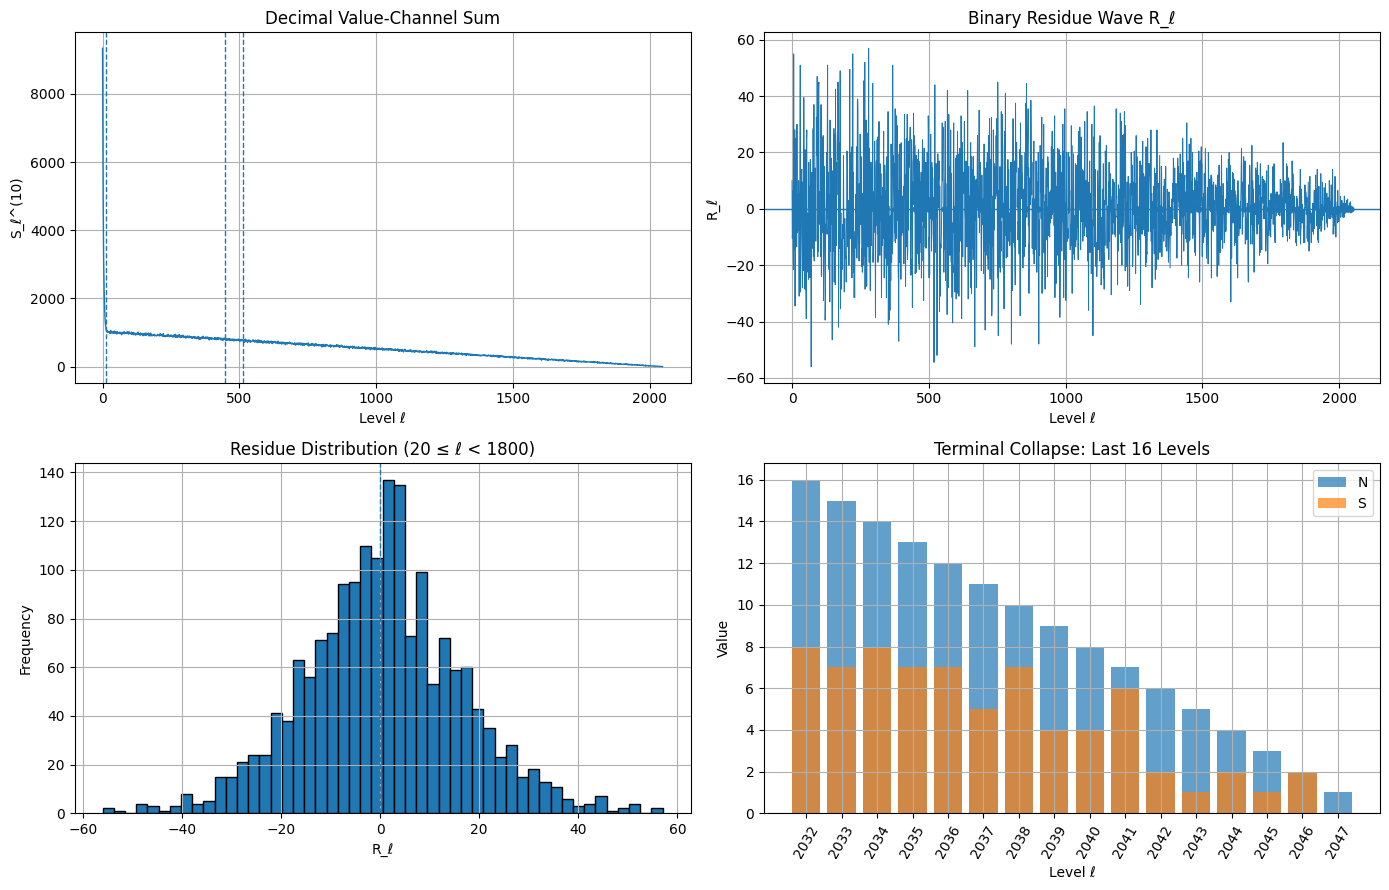

In [17]:
# Cell 17 — Trace visualizations

if RUN_VISUALS:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0,0].plot(decimal_S, linewidth=1)
    for level in [13, 448, 512]:
        axes[0,0].axvline(level, linestyle="--", linewidth=1)
    axes[0,0].set_title("Decimal Value-Channel Sum")
    axes[0,0].set_xlabel("Level ℓ")
    axes[0,0].set_ylabel("S_ℓ^(10)")

    R = binary_trace["R"]
    axes[0,1].plot(R, linewidth=0.7)
    axes[0,1].scatter(binary_trace["locks"], [0]*len(binary_trace["locks"]), s=12)
    axes[0,1].axhline(0, linewidth=1)
    axes[0,1].set_title("Binary Residue Wave R_ℓ")
    axes[0,1].set_xlabel("Level ℓ")
    axes[0,1].set_ylabel("R_ℓ")

    segment = R[20:1800]
    axes[1,0].hist(segment, bins=50, edgecolor="black")
    axes[1,0].axvline(0, linestyle="--", linewidth=1)
    axes[1,0].set_title("Residue Distribution (20 ≤ ℓ < 1800)")
    axes[1,0].set_xlabel("R_ℓ")
    axes[1,0].set_ylabel("Frequency")

    last_levels = list(range(2032, 2048))
    axes[1,1].bar([str(l) for l in last_levels], binary_trace["N"][last_levels], alpha=0.7, label="N")
    axes[1,1].bar([str(l) for l in last_levels], binary_trace["S"][last_levels], alpha=0.7, label="S")
    axes[1,1].set_title("Terminal Collapse: Last 16 Levels")
    axes[1,1].set_xlabel("Level ℓ")
    axes[1,1].set_ylabel("Value")
    axes[1,1].tick_params(axis="x", rotation=60)
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Visuals skipped.")


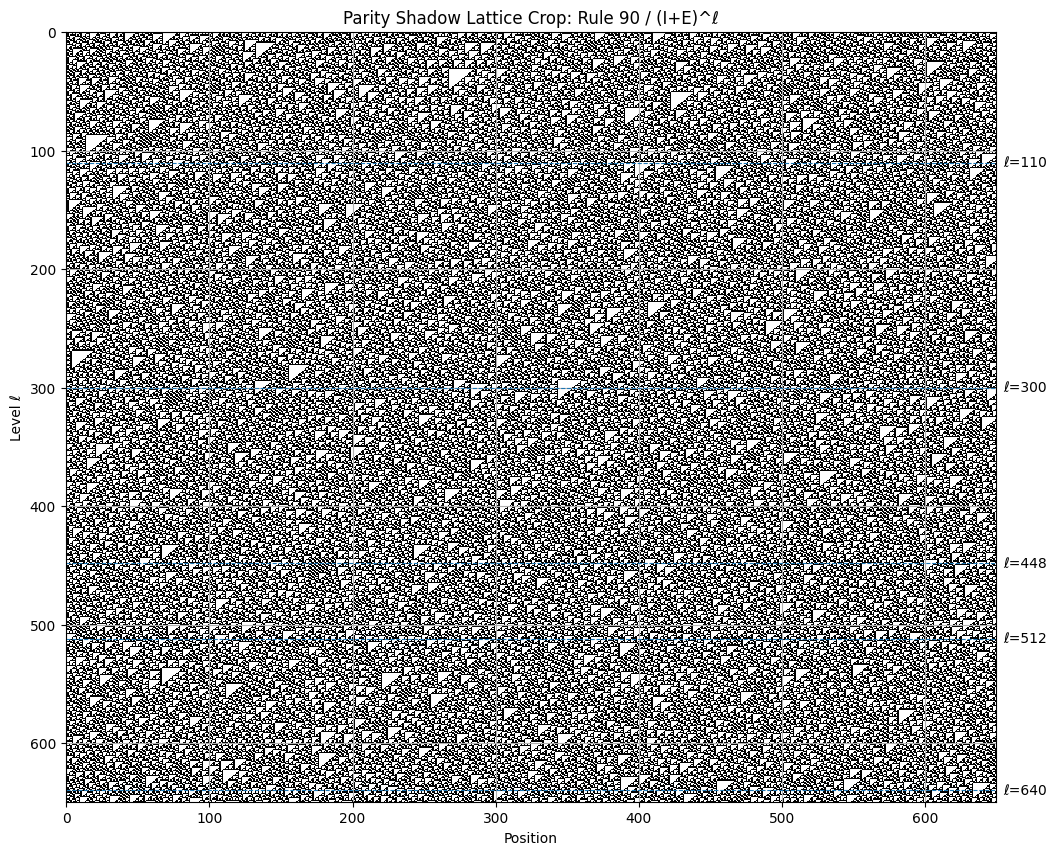

In [18]:
# Cell 18 — Parity shadow lattice crop

if RUN_VISUALS:
    max_levels = 650
    max_cols = 650

    img = np.ones((max_levels, max_cols), dtype=float)
    for level in range(max_levels):
        row = xor_lattice[level][:max_cols]
        for i, bit in enumerate(row):
            img[level, i] = 0.0 if bit else 1.0

    plt.figure(figsize=(12, 10))
    plt.imshow(img, cmap="gray", aspect="auto", interpolation="nearest")
    for level in [110, 300, 448, 512, 640]:
        plt.axhline(level, linestyle="--", linewidth=0.8)
        plt.text(max_cols + 5, level, f"ℓ={level}", va="center")
    plt.title("Parity Shadow Lattice Crop: Rule 90 / (I+E)^ℓ")
    plt.xlabel("Position")
    plt.ylabel("Level ℓ")
    plt.show()
else:
    print("Visuals skipped.")


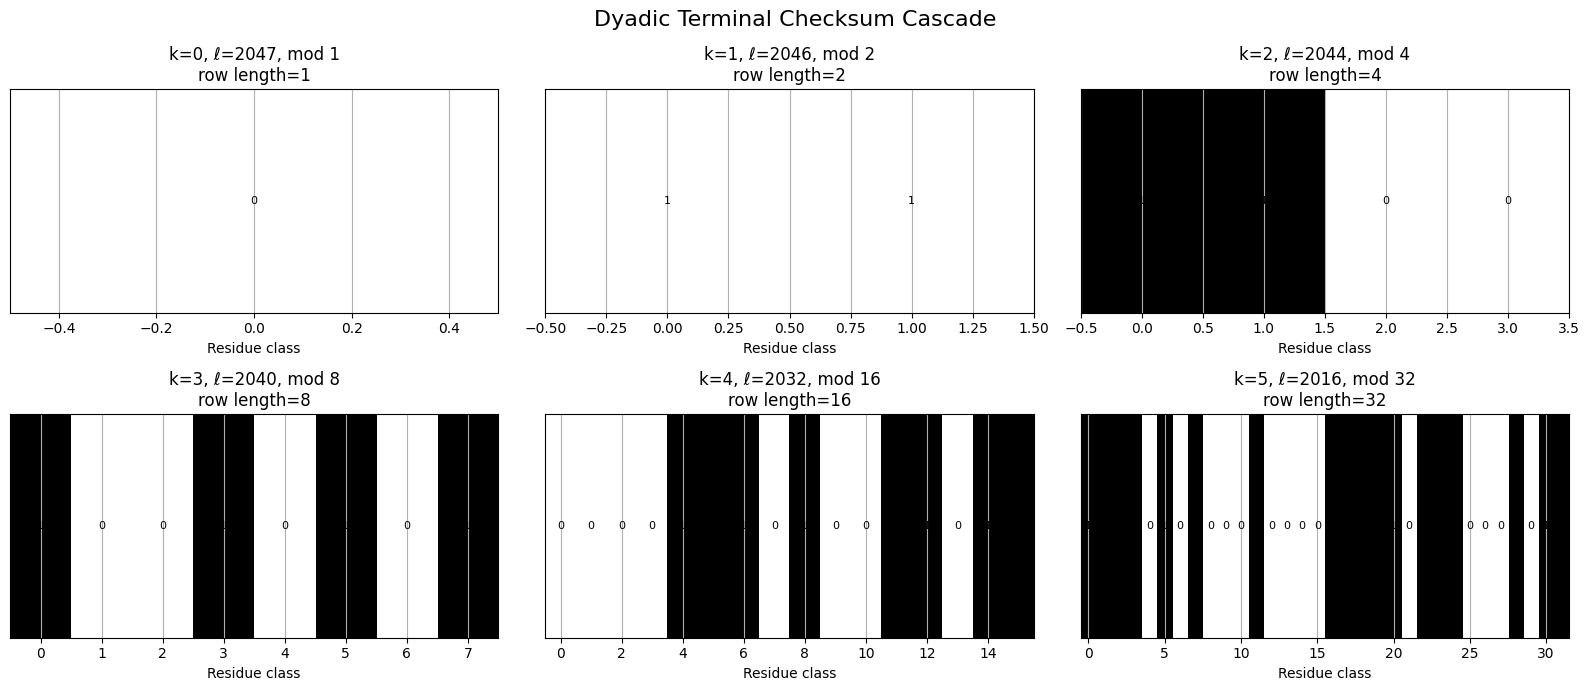

In [19]:
# Cell 19 — Dyadic terminal cascade visualization

if RUN_VISUALS:
    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    axes = axes.ravel()

    for idx, k in enumerate(range(0, 6)):
        level = N - (1 << k)
        row = xor_lattice[level]
        ax = axes[idx]
        ax.imshow(np.array([row]), cmap="gray_r", aspect="auto", interpolation="nearest")
        ax.set_title(f"k={k}, ℓ={level}, mod {1<<k}\nrow length={len(row)}")
        ax.set_yticks([])
        ax.set_xlabel("Residue class")
        for i, bit in enumerate(row):
            ax.text(i, 0, str(bit), ha="center", va="center", fontsize=8)

    plt.suptitle("Dyadic Terminal Checksum Cascade", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Visuals skipped.")


# 22. Final Validation Cell

This cell gathers the main addendum checks in one place.


In [20]:
# Cell 20 — Final validation summary

checks = {
    "decimal_S0": int(decimal_S[0]) == 9338,
    "decimal_S13": int(decimal_S[13]) == 1092,
    "parity_shadow_exact": bad is None,
    "level_448_lock": (
        int(binary_trace["N"][448]) == 1600 and
        int(binary_trace["S"][448]) == 800 and
        float(binary_trace["R"][448]) == 0.0
    ),
    "level_512_lock": (
        int(binary_trace["N"][512]) == 1536 and
        int(binary_trace["S"][512]) == 764 and
        float(binary_trace["R"][512]) == -4.0
    ),
    "terminal_gate": xor_lattice[2046] == [1, 1] and xor_lattice[2047] == [0],
    "full_R_counts": len(zero_R_levels) == 44 and len(nonzero_R_levels) == 2004,
    "interior_R_counts": len(interior_zero) == 30 and len(interior_nonzero) == 1750,
    "dyadic_theorem": all(ok for _, _, _, ok, _ in dyadic_summary),
}

if RUN_FULL_RANK:
    checks.update({
        "rank_dyadic": rank_dyadic == 1024,
        "rank_448": rank_448 == 1600,
        "rank_512": rank_512 == 1536,
        "rank_dyadic_448": rank_dyadic_448 == 1600,
        "nullity_after_dyadic_448": (N - rank_dyadic_448) == 448,
    })

print("FINAL VALIDATION")
print("=" * 80)
for name, ok in checks.items():
    print(f"{name:30s}: {ok}")

assert all(checks.values())

print()
print("FOLD-TOMO-02 validation complete.")
print("Core executable collapse: 2048 -> 1600 -> 448")


FINAL VALIDATION
decimal_S0                    : True
decimal_S13                   : True
parity_shadow_exact           : True
level_448_lock                : True
level_512_lock                : True
terminal_gate                 : True
full_R_counts                 : True
interior_R_counts             : True
dyadic_theorem                : True
rank_dyadic                   : True
rank_448                      : True
rank_512                      : True
rank_dyadic_448               : True
nullity_after_dyadic_448      : True

FOLD-TOMO-02 validation complete.
Core executable collapse: 2048 -> 1600 -> 448


# 23. Final Formula Stack

$$
\Delta:
\quad
d_i^{(\ell+1)}
=
\left|
d_{i+1}^{(\ell)}-d_i^{(\ell)}
\right|
$$

$$
\oplus:
\quad
x_i^{(\ell+1)}
=
x_i^{(\ell)}
\oplus
x_{i+1}^{(\ell)}
$$

$$
↻:
\quad
x^{(\ell)}
=
(I+E)^\ell x^{(0)}
$$

$$
\bot:
\quad
x_i^{(\ell)}
=
\bigoplus_{j\subseteq\ell}x_{i+j}^{(0)}
$$

$$
\Psi:
\quad
Cx=y,
\qquad
x=x_0+Bz,
\qquad
\operatorname{wt}\left(A_\ell(x_0+Bz)\right)=S_\ell
$$

Final lock:

$$
\boxed{
\text{Forward collapse hides address; reverse recovery restores address by reading shape.}
}
$$
